### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter_analisis_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter_analisis_datos.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

In [1]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


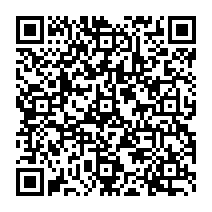

In [2]:
url = "https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/12_chapter_analisis_datos.ipynb"
generar_qr(url) 

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno](https://www.youtube.com/watch?v=b5gwgxPR-Sk)

### [Vínculo al programa del curso de Fundamentos de Programación:](https://github.com/marco-canas/fundamentos_de_programacion/blob/main/programa/Programa_Fundamentos_Programacion.md)



## Código del curso: 314029

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/algebra_y_trigonometria/blob/main/7_images/5_clase_3_2025-08-12_hora_11_04.jpg?raw=true' width = 800> 




# CAPÍTULO 12: Análisis de Datos Paso a Paso



# Objetivos de la Clase

* Aplicar de forma integrada los conocimientos previos de **Python, Pandas, NumPy y Matplotlib** al análisis de datos.


* Aprender a limpiar a través de imputación de datos y a  extraer conclusiones de un conjunto de datos crudos.


* Seguir el flujo de trabajo real de un Científico de Datos ante un problema de negocio.



# 1. Definición de un Problema Empresarial (Problem Statement)



En Ciencia de Datos, nunca empezamos a programar sin un objetivo de negocio. 

Aquí planteamos las preguntas que queremos responder.  


> * **Problema:** La empresa ha detectado una fuga de clientes en ciertos segmentos, pero no sabe exactamente qué grupo tiene el menor índice de satisfacción ni cómo influyen sus ingresos en sus decisiones de compra.
> * **Meta del Análisis:** Identificar el perfil de cliente insatisfecho y proponer un patrón visual de comportamiento mediante gráficos.


# 2. Importando el Dataset en un DataFrame



> Importación de las librerías base y carga del archivo de datos (CSV, Excel o JSON).



Para que esta simulación sea verdaderamente útil e interesante desde la perspectiva de la **Administración de Empresas** en el contexto de **Caucasia, Antioquia**, debemos inyectarle la realidad socioeconómica de la subregión del Bajo Cauca antioqueño.



# El Contexto del Negocio en Caucasia



Caucasia es la capital comercial del Bajo Cauca. 

<img src = 'https://corregimientos.antioquia.gov.co/wp-content/uploads/2023/04/Mapas-Caucasia-Corregido_Mesa-de-trabajo-1-2048x2048.jpg'>

Su economía se mueve fuertemente gracias al 
   * **comercio local,** 
   * **la ganadería,** 
   * **la minería de oro** y 
   * **el sector de servicios/agroindustria**. 

<img src = 'https://acopiantioquia.org/web/image/52767-7719ae72/Portada-bajocauca-web.jpg'>

Una problemática empresarial real en la zona es **la retención de clientes o microempresarios** frente a las condiciones de ingresos (muchas veces informales o variables) y el acceso al crédito.



Para que los gráficos revelen un problema real, **no podemos dejar los datos al azar (`np.random.choice` o `normal`)**. 

Debemos forzar **correlaciones ocultas** (un patrón) para que tu análisis descubra que, por ejemplo: *Los comerciantes de ingresos medios/bajos tienen un score bajo y una satisfacción pésima debido a las tasas de interés o condiciones del servicio.*


<img src = comerciantes_de_ingresos_medios_bajos.png>


Aquí tienes el código mejorado y adaptado, listo para ejecutar:


In [3]:
# Importación de librerías esenciales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


<img src = '1_importacion_librerias.png'>

In [4]:

# Configurar semilla para reproducibilidad
np.random.seed(513)# esto es para que los números aleatorios sean siempre los mismo. 


<img src = '2_establecimiento_semilla_aleatoria.png'>

In [5]:
n_clientes = 100  # Ampliamos a 100 para enriquecer el análisis

# 1. Generación de datos base coherentes con la región
ids = np.arange(1001, 1001 + n_clientes)
ids   

array([1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011,
       1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022,
       1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033,
       1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 1044,
       1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055,
       1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064, 1065, 1066,
       1067, 1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075, 1076, 1077,
       1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088,
       1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099,
       1100])

<img src = '3_tamaño_muestra_indices.png'>

In [6]:
fechas = pd.date_range(start='2026-05-01', periods=n_clientes, freq='D')
fechas

DatetimeIndex(['2026-05-01', '2026-05-02', '2026-05-03', '2026-05-04',
               '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08',
               '2026-05-09', '2026-05-10', '2026-05-11', '2026-05-12',
               '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-16',
               '2026-05-17', '2026-05-18', '2026-05-19', '2026-05-20',
               '2026-05-21', '2026-05-22', '2026-05-23', '2026-05-24',
               '2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28',
               '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01',
               '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05',
               '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13',
               '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17',
               '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
      

<img src = '4_date_range.png'>

In [7]:

# Perfiles económicos típicos en Caucasia
np.random.seed(513) # para que los números aleatorios sean siempre los mismo.
sectores = ['Comercio Minorista', 'Ganadería/Agro', 'Minería/Servicios', 'Independientes']
perfil_comercial = np.random.choice(sectores, n_clientes, p = [0.4, 0.2, 0.2, 0.2])
perfil_comercial  

array(['Comercio Minorista', 'Comercio Minorista', 'Minería/Servicios',
       'Comercio Minorista', 'Minería/Servicios', 'Comercio Minorista',
       'Ganadería/Agro', 'Comercio Minorista', 'Independientes',
       'Ganadería/Agro', 'Minería/Servicios', 'Independientes',
       'Minería/Servicios', 'Independientes', 'Ganadería/Agro',
       'Minería/Servicios', 'Comercio Minorista', 'Ganadería/Agro',
       'Independientes', 'Ganadería/Agro', 'Ganadería/Agro',
       'Ganadería/Agro', 'Minería/Servicios', 'Minería/Servicios',
       'Ganadería/Agro', 'Independientes', 'Minería/Servicios',
       'Minería/Servicios', 'Ganadería/Agro', 'Independientes',
       'Comercio Minorista', 'Comercio Minorista', 'Comercio Minorista',
       'Ganadería/Agro', 'Minería/Servicios', 'Minería/Servicios',
       'Independientes', 'Ganadería/Agro', 'Ganadería/Agro',
       'Comercio Minorista', 'Independientes', 'Independientes',
       'Independientes', 'Comercio Minorista', 'Comercio Minorista',
    

<img src = 'sectores_economicos.png'>

In [8]:

# 2. Generar Ingresos Mensuales (en COP) adaptados al contexto local
# Los ganaderos/mineros suelen registrar mayores ingresos que los comerciantes minoristas e independientes.
ingresos = []
for perfil in perfil_comercial:
    if perfil == 'Ganadería/Agro' or perfil == 'Minería/Servicios':
        ingresos.append(np.random.normal(5_500_000, 1_200_000)) # Ingresos más altos
    else:
        ingresos.append(np.random.normal(2_300_000, 600_000))  # Pequeño comercio / Independientes

ingresos = np.array(ingresos).round(2)
ingresos 

array([2325131.79, 3181586.69, 4720182.31, 2357343.7 , 6790040.76,
       1437155.58, 3470482.03, 2842338.64, 1630269.55, 3993344.89,
       4429862.71, 2824021.76, 6247853.49, 3330926.36, 5272935.72,
       5205050.32, 2688431.79, 3448463.37, 2330134.27, 2851115.95,
       6190715.35, 5077568.73, 3646622.68, 5064496.49, 6654440.78,
       1732714.19, 3675314.05, 4097685.63, 6723570.79, 2900753.29,
       2375121.9 , 2551251.25, 2960332.07, 4836298.93, 4609063.82,
       5898880.25, 2160617.24, 5653499.12, 4559220.88, 2962021.25,
       1857438.13, 1886533.84, 2279513.27, 2476780.01, 3473190.44,
       5790630.8 , 5289461.76, 1426301.61, 1676393.99, 2399408.95,
       1818438.99, 2959483.77, 2580236.87, 4878762.97, 1887119.49,
       7545565.76, 2620032.48, 3115060.1 , 7206104.59, 1859172.71,
       2332744.25, 1987325.76, 4999109.24, 3688177.43, 5545821.89,
       2034866.1 , 1701681.22, 2217195.2 , 2365027.96, 7101627.18,
       1984984.87, 2179157.64, 2278152.54, 5158263.56, 6145559

(array([  3.,   6.,  10.,   7.,  21.,  57.,  75.,  87.,  89., 113., 124.,
        123.,  95.,  64.,  65.,  28.,  18.,   8.,   5.,   2.]),
 array([2.46701244, 2.61781921, 2.76862598, 2.91943275, 3.07023952,
        3.22104629, 3.37185305, 3.52265982, 3.67346659, 3.82427336,
        3.97508013, 4.12588689, 4.27669366, 4.42750043, 4.5783072 ,
        4.72911397, 4.87992074, 5.0307275 , 5.18153427, 5.33234104,
        5.48314781]),
 <BarContainer object of 20 artists>)

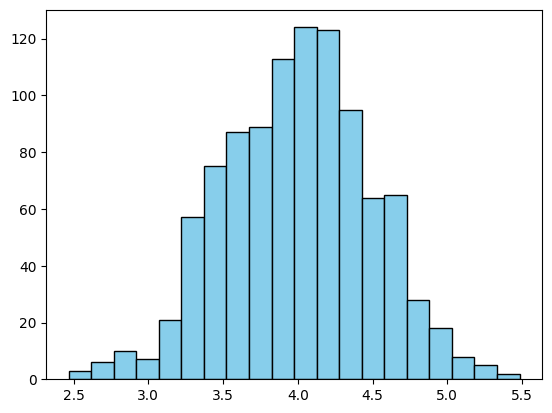

In [9]:
notas = np.random.normal(4, 0.5, 1_000)  

plt.hist(notas, bins=20, color='skyblue', edgecolor='black')

In [10]:

# 3. Generar Score de Crédito (Escala Datacrédito/Cifín: 300 a 850)
# Vinculamos el score al nivel de ingresos (a menor ingreso, mayor probabilidad de score bajo por riesgos informales)
score_credito = []
for ing in ingresos:
    factor_error = np.random.randint(-150, 150)
    # Base de score proporcional al ingreso + ruido aleatorio
    score = int(350 + (ing / 15_000) + factor_error)
    score_credito.append(max(300, min(850, score))) # Mantener en rango legal

score_credito = np.array(score_credito)
score_credito  

array([424, 698, 722, 643, 652, 409, 544, 679, 565, 515, 709, 396, 784,
       673, 669, 723, 578, 640, 475, 655, 753, 757, 562, 741, 656, 504,
       742, 725, 695, 527, 505, 443, 428, 770, 637, 785, 540, 823, 760,
       459, 358, 518, 561, 606, 651, 739, 835, 317, 451, 377, 414, 614,
       508, 631, 603, 850, 495, 633, 850, 410, 626, 546, 739, 499, 615,
       380, 413, 369, 520, 850, 576, 504, 406, 786, 734, 498, 609, 439,
       499, 380, 630, 390, 652, 653, 770, 809, 582, 592, 408, 548, 562,
       548, 546, 751, 400, 600, 490, 759, 796, 503])

# Háblemos del significado del score crediticio  

En el contexto de la analítica y la ciencia de datos, el **score crediticio (o puntaje de crédito)** es una variable numérica que mide el **riesgo financiero de una persona o entidad**. 

En términos sencillos, es una predicción estadística de qué tan probable es que un cliente pague sus deudas a tiempo o, por el contrario, caiga en incumplimiento (*default*).



En la práctica de análisis de datos que estructuramos, el score crediticio cumple funciones clave tanto desde la perspectiva técnica como desde la de negocio:



## 1. El Significado Técnico (Tipos de Variable)

Cuando trabajas con el score crediticio en Python (usando Pandas o NumPy), lo analizas bajo dos ópticas fundamentales:



* **Como Variable Numérica Continua/Discreta:** Originalmente, suele ser un número entero (por ejemplo, en sistemas reales como FICO, va de **300 a 850** puntos). 

Esto te permite calcular medias, desviaciones estándar y buscar correlaciones con otras variables numéricas (como los ingresos).


* **Como Variable Categórica Ordinal (Tras la transformación):** En el código utilizamos la función `categorizar_score` para transformar esos números en etiquetas (`'Pobre'`, `'Regular'`, `'Excelente'`). 

Esto se conoce como **segmentación o *binning***, y facilita la agrupación de datos para crear tabulaciones y gráficos más fáciles de entender para los tomadores de decisiones.



## 2. El Significado de Negocio (¿Para qué sirve analizarlo?)

En un caso de uso real de Ciencia de Datos orientado a clientes, cruzar el score crediticio con otras variables (como el nivel de satisfacción o el dinero gastado) te permite responder preguntas estratégicas:



* **Segmentación de Clientes de Alto Valor:** Un cliente con ingresos estables y un score crediticio "Excelente" es un cliente de bajo riesgo. 

El análisis de datos ayuda a identificarlos para ofrecerles beneficios exclusivos, membresías premium o créditos preaprobados.


* **Detección de Alertas de Fuga (Churn):** Si el análisis demuestra que los clientes con scores crediticios altos tienen una **satisfacción baja** (valores de 1 o 2), es una señal de alarma crítica: la empresa está frustrando a sus clientes más solventes y con mayor capacidad de gasto, quienes podrían irse fácilmente a la competencia.


* **Mitigación del Riesgo:** Permite correlacionar si las personas que compran ciertos productos específicos (por ejemplo, tecnología de alta gama) tienden a financiarlo teniendo un score crediticio "Pobre", lo que ayuda al departamento de riesgos a ajustar las políticas de aprobación de compras.




## 3. ¿Cómo se interpreta en los gráficos del ejercicio?

En el ejercicio práctico de Jupyter, al graficar el score en el eje $Y$ contra los ingresos en el eje $X$, el analista busca patrones visuales:



* Si los puntos con puntuaciones altas de crédito se concentran en colores que representan "alta satisfacción", la estrategia de retención actual funciona.


* Si los puntos están dispersos sin orden, significa que el score crediticio no influye directamente en cómo el cliente percibe la marca, obligando al científico de datos a buscar otras variables predictivas.

In [11]:

# 4. CREAR LA FUGA Y LA INSATISFACCIÓN (El patrón oculto que el Administrador debe hallar)
# Hipótesis administrativa: El sector "Comercio Minorista" con ingresos bajos (< 2.5M) 
# y score bajo está sufriendo de mala atención o condiciones de crédito muy duras.
satisfaccion = []
for i in range(n_clientes):
    # Condición de nulos (10% de probabilidad general para practicar imputación)
    if np.random.rand() < 0.10:
        satisfaccion.append(np.nan)
        continue
        
    perfil = perfil_comercial[i]
    ing = ingresos[i]
    
    # Si pertenece al segmento crítico: Comercio Minorista o Independiente con bajos ingresos
    if (perfil in ['Comercio Minorista', 'Independientes']) and (ing < 2_500_000):
        # Alta probabilidad de insatisfacción (Notas 1 o 2)
        satisfaccion.append(np.random.choice([1, 2, 3], p=[0.5, 0.4, 0.1]))
    else:
        # Clientes estables o de sectores de mayor ingreso (Notas 4 o 5)
        satisfaccion.append(np.random.choice([3, 4, 5], p=[0.2, 0.5, 0.3]))
satisfaccion = np.array(satisfaccion)
satisfaccion    

array([ 1.,  4.,  4.,  2.,  4.,  1.,  5., nan,  2.,  3.,  5.,  3., nan,
        3.,  3.,  5.,  4.,  4.,  1.,  3.,  4.,  5.,  5.,  4.,  5.,  1.,
        4.,  4., nan,  5.,  1.,  4.,  3.,  3.,  4.,  4.,  1.,  3.,  4.,
        4.,  2., nan,  2.,  1., nan,  4.,  3.,  1.,  1.,  1.,  2.,  3.,
        4.,  4.,  1.,  4.,  5.,  4.,  4.,  1.,  2.,  3., nan,  5., nan,
       nan,  1., nan,  2.,  5.,  1.,  1.,  1.,  5.,  3.,  3., nan, nan,
       nan,  1.,  4.,  2.,  5.,  1.,  4.,  4.,  4.,  1.,  1., nan,  2.,
        1.,  3.,  5.,  1.,  5.,  3.,  3.,  5.,  2.])

In [12]:

# 5. Segmentación del Perfil de Crédito (Regla Administrativa bancaria o comercial)
perfil_credito = []
for score in score_credito:
    if score < 500: 
        perfil_credito.append('Alto Riesgo')
    elif score < 700: 
        perfil_credito.append('Riesgo Medio')
    else: 
        perfil_credito.append('Premium / Excelente')
perfil_credito  = np.array(perfil_credito)
perfil_credito  

array(['Alto Riesgo', 'Riesgo Medio', 'Premium / Excelente',
       'Riesgo Medio', 'Riesgo Medio', 'Alto Riesgo', 'Riesgo Medio',
       'Riesgo Medio', 'Riesgo Medio', 'Riesgo Medio',
       'Premium / Excelente', 'Alto Riesgo', 'Premium / Excelente',
       'Riesgo Medio', 'Riesgo Medio', 'Premium / Excelente',
       'Riesgo Medio', 'Riesgo Medio', 'Alto Riesgo', 'Riesgo Medio',
       'Premium / Excelente', 'Premium / Excelente', 'Riesgo Medio',
       'Premium / Excelente', 'Riesgo Medio', 'Riesgo Medio',
       'Premium / Excelente', 'Premium / Excelente', 'Riesgo Medio',
       'Riesgo Medio', 'Riesgo Medio', 'Alto Riesgo', 'Alto Riesgo',
       'Premium / Excelente', 'Riesgo Medio', 'Premium / Excelente',
       'Riesgo Medio', 'Premium / Excelente', 'Premium / Excelente',
       'Alto Riesgo', 'Alto Riesgo', 'Riesgo Medio', 'Riesgo Medio',
       'Riesgo Medio', 'Riesgo Medio', 'Premium / Excelente',
       'Premium / Excelente', 'Alto Riesgo', 'Alto Riesgo', 'Alto Riesgo',
 

In [13]:

# Construcción del DataFrame Final
data = {
    'identificador_cliente': ids,
    'fecha_afiliacion': fechas,
    'sector_economico': perfil_comercial,
    'ingresos_mensuales_cop': ingresos,
    'score_credito': score_credito,
    'perfil_credito': perfil_credito,
    'satisfaccion': satisfaccion
}
data 

{'identificador_cliente': array([1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011,
        1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022,
        1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033,
        1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 1044,
        1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055,
        1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064, 1065, 1066,
        1067, 1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075, 1076, 1077,
        1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088,
        1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099,
        1100]),
 'fecha_afiliacion': DatetimeIndex(['2026-05-01', '2026-05-02', '2026-05-03', '2026-05-04',
                '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08',
                '2026-05-09', '2026-05-10', '2026-05-11', '2026-05-12',
                '2026-05-13', '2026-05-14', '2026-05-15',

# El dataset al que le realizaremos el Análisis de datos 

In [14]:
import pandas as pd 
df = pd.DataFrame(data)

# Mostrar los primeros registros y un resumen estratégico
print("--- Dataset de Clientes - Caucasia (Antioquia) ---")
df  


--- Dataset de Clientes - Caucasia (Antioquia) ---


,identificador_cliente,fecha_afiliacion,sector_economico,ingresos_mensuales_cop,score_credito,perfil_credito,satisfaccion
0,1001,2026-05-01,Comercio Minorista,2325131.79,424,Alto Riesgo,1.0
1,1002,2026-05-02,Comercio Minorista,3181586.69,698,Riesgo Medio,4.0
2,1003,2026-05-03,Minería/Servicios,4720182.31,722,Premium / Excelente,4.0
3,1004,2026-05-04,Comercio Minorista,2357343.70,643,Riesgo Medio,2.0
4,1005,2026-05-05,Minería/Servicios,6790040.76,652,Riesgo Medio,4.0
...,...,...,...,...,...,...,...
95,1096,2026-08-04,Comercio Minorista,2852582.21,600,Riesgo Medio,5.0
96,1097,2026-08-05,Independientes,2549969.81,490,Alto Riesgo,3.0
97,1098,2026-08-06,Ganadería/Agro,5023156.65,759,Premium / Excelente,3.0
98,1099,2026-08-07,Ganadería/Agro,5809968.80,796,Premium / Excelente,5.0


# Describir el segmento de clientes más insatisfecho para tomar decisiones centradas en este segmento

# Síntesis tabular de los datos 

## Mapa conceptual de la síntesis tabular 

In [15]:
!pip install graphviz

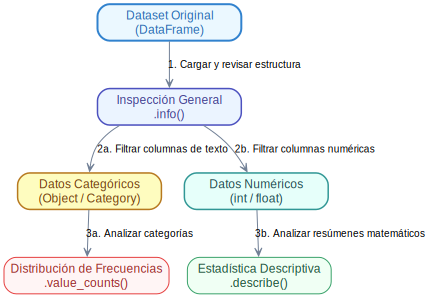

In [16]:
import graphviz

# Crear el objeto Digraph (Gráfico Dirigido)
dot = graphviz.Digraph(comment='Proceso de Visualización Tabular', format='png')

# Configuraciones globales del gráfico para que se vea moderno
dot.attr(rankdir='TB', size='8,8')
dot.attr('node', fontname='Helvetica', fontsize='12', shape='box', style='filled, rounded', width='2')
dot.attr('edge', fontname='Helvetica', fontsize='10', color='#718096', arrowhead='vee', arrowsize='0.8')

# Definición de Nodos con colores específicos (Paleta en Hexadecimal)
# Nodo Raíz
dot.node('DF', 'Dataset Original\n(DataFrame)', fillcolor='#EBF8FF', color='#3182CE', fontcolor='#2B6CB0', penwidth='2')

# Nivel 1: Inspección General
dot.node('INFO', 'Inspección General\n.info()', fillcolor='#EBF4FF', color='#4C51BF', fontcolor='#434190', penwidth='1.5')

# Nivel 2: Subdivisión de tipos de datos
dot.node('CAT', 'Datos Categóricos\n(Object / Category)', fillcolor='#FEFCBF', color='#B7791F', fontcolor='#744210', penwidth='1.5')
dot.node('NUM', 'Datos Numéricos\n(int / float)', fillcolor='#E6FFFA', color='#319795', fontcolor='#234E52', penwidth='1.5')

# Nivel 3: Métodos de visualización específicos
dot.node('VC', 'Distribución de Frecuencias\n.value_counts()', fillcolor='#FFF5F5', color='#E53E3E', fontcolor='#9B2C2C')
dot.node('DESC', 'Estadística Descriptiva\n.describe()', fillcolor='#F0FFF4', color='#38A169', fontcolor='#22543D')

# Creación de las conexiones (Aristas / Edges) con texto descriptivo
dot.edge('DF', 'INFO', label=' 1. Cargar y revisar estructura')
dot.edge('INFO', 'CAT', label=' 2a. Filtrar columnas de texto')
dot.edge('INFO', 'NUM', label=' 2b. Filtrar columnas numéricas')
dot.edge('CAT', 'VC', label=' 3a. Analizar categorías')
dot.edge('NUM', 'DESC', label=' 3b. Analizar resúmenes matemáticos')

# En Jupyter (y VS Code), simplemente llamando al objeto al final de la celda 
# se renderiza automáticamente el mapa conceptual en pantalla.}
dot.render(r"C:\Users\marco\Downloads\mapa_conceptual_analisis_datos", view=False)  # Guarda el archivo pero no lo abre automáticamente
dot

In [17]:
df.info()
# me da los datos faltantes 
# me dijo la naturaleza de las variables (cuanti o cuali, continuia o discreta, o nominal u ortinal )
# El tipo de gráfico Cualitativa nominal debe utilizar gráfico de barras o diagrama circular 

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   identificador_cliente   100 non-null    int64         
 1   fecha_afiliacion        100 non-null    datetime64[us]
 2   sector_economico        100 non-null    str           
 3   ingresos_mensuales_cop  100 non-null    float64       
 4   score_credito           100 non-null    int64         
 5   perfil_credito          100 non-null    str           
 6   satisfaccion            87 non-null     float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 5.6 KB


# Observaciones del resumen tabular general  

1. Solo el atributo de satisfacción tiene valores faltantes. (Hay que hacer tratamiento de datos faltantes)
2. Hay una variable cuyos datos son de fecha y hora. (El dataset es una serie de tiempo)
3. Hay dos variables categóricas o de tipo objects o tipo str. (Visualización tabular debes ser con value_counts() y la gráfica debe ser con disgrama tipo pie, barras)
4. Todas las variables numéricas son de tipo entero, es decir, numéricas discretas. (La visualización tabular sea con .discribe() y la gráfica sea con histogramas y diagramas de dispersión)

# Resumen tabular pero para variables categóricas 

# Visualización tabular de datos categóricos  

In [18]:
print("\n--- Conteo de Clientes por Sector ---")
df['sector_economico'].value_counts()



--- Conteo de Clientes por Sector ---


sector_economico
Comercio Minorista    32
Independientes        25
Ganadería/Agro        22
Minería/Servicios     21
Name: count, dtype: int64

In [19]:
df.columns # para consultar el nombre de todas las columnas del dataframe 

Index(['identificador_cliente', 'fecha_afiliacion', 'sector_economico',
       'ingresos_mensuales_cop', 'score_credito', 'perfil_credito',
       'satisfaccion'],
      dtype='str')

In [20]:
print("\n--- Conteo de Clientes por Perfil de Crédito ---")
df['perfil_credito'].value_counts()


--- Conteo de Clientes por Perfil de Crédito ---


perfil_credito
Riesgo Medio           47
Alto Riesgo            27
Premium / Excelente    26
Name: count, dtype: int64

# Visualización tabular de datos numéricos 

In [21]:
df.describe().round(0)

,identificador_cliente,fecha_afiliacion,ingresos_mensuales_cop,score_credito,satisfaccion
count,100.0,100,100.0,100.0,87.0
mean,1050.0,2026-06-19 12:00:00,3574528.0,594.0,3.0
min,1001.0,2026-05-01 00:00:00,1426302.0,317.0,1.0
25%,1026.0,2026-05-25 18:00:00,2279173.0,499.0,2.0
50%,1050.0,2026-06-19 12:00:00,2961177.0,596.0,3.0
75%,1075.0,2026-07-14 06:00:00,4962336.0,712.0,4.0
max,1100.0,2026-08-08 00:00:00,7545566.0,850.0,5.0
std,29.0,NaN,1623412.0,137.0,1.0



# 4. Limpiando y Preparando los Datos (EDA)
## Tratamiento de valores faltantes: llenado de valores faltantes 

> Esta es la fase donde pasamos el 70% del tiempo en Ciencia de Datos. 

Buscaremos datos faltantes (nulos), tipos de datos incorrectos y valores atípicos (*outliers*).


In [22]:
# 4.1 Exploración Inicial
print("--- Información General del DataFrame ---")
df.info()


--- Información General del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   identificador_cliente   100 non-null    int64         
 1   fecha_afiliacion        100 non-null    datetime64[us]
 2   sector_economico        100 non-null    str           
 3   ingresos_mensuales_cop  100 non-null    float64       
 4   score_credito           100 non-null    int64         
 5   perfil_credito          100 non-null    str           
 6   satisfaccion            87 non-null     float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 5.6 KB


In [23]:

# 4.2 Identificación y Limpieza de Valores Nulos
print("\n--- Valores Faltantes por Columna ---")
print(df.isnull().sum())



--- Valores Faltantes por Columna ---
identificador_cliente      0
fecha_afiliacion           0
sector_economico           0
ingresos_mensuales_cop     0
score_credito              0
perfil_credito             0
satisfaccion              13
dtype: int64


In [24]:

# Estrategia de Limpieza: Imputar los nulos en 'satisfaccion' con la mediana
mediana_satisfaccion = df['satisfaccion'].median()
mediana_satisfaccion

np.float64(3.0)

In [25]:
np.sort(df.satisfaccion.values)[44:45]   

array([3.])

In [26]:
df['satisfaccion'] = df['satisfaccion'].fillna(mediana_satisfaccion)


In [27]:
df.isnull().sum()  

identificador_cliente     0
fecha_afiliacion          0
sector_economico          0
ingresos_mensuales_cop    0
score_credito             0
perfil_credito            0
satisfaccion              0
dtype: int64

In [28]:
print(f"\n Valores nulos de satisfacción imputados con la mediana: {mediana_satisfaccion}")
df['satisfaccion'].isnull().sum()


 Valores nulos de satisfacción imputados con la mediana: 3.0


np.int64(0)

# Crear un atributo categórico nuevo a partir de la segmentación de una variable numérica

In [29]:
# 4.3 Selección y Filtrado de Datos
# Supongamos que solo nos interesan clientes con ingresos mayores a 1500 para este estudio
df_filtrado = df[df['ingresos_mensuales_cop'] > 2_000_000].copy()

In [30]:
df_filtrado

,identificador_cliente,fecha_afiliacion,sector_economico,ingresos_mensuales_cop,score_credito,perfil_credito,satisfaccion
0,1001,2026-05-01,Comercio Minorista,2325131.79,424,Alto Riesgo,1.0
1,1002,2026-05-02,Comercio Minorista,3181586.69,698,Riesgo Medio,4.0
2,1003,2026-05-03,Minería/Servicios,4720182.31,722,Premium / Excelente,4.0
3,1004,2026-05-04,Comercio Minorista,2357343.70,643,Riesgo Medio,2.0
4,1005,2026-05-05,Minería/Servicios,6790040.76,652,Riesgo Medio,4.0
...,...,...,...,...,...,...,...
95,1096,2026-08-04,Comercio Minorista,2852582.21,600,Riesgo Medio,5.0
96,1097,2026-08-05,Independientes,2549969.81,490,Alto Riesgo,3.0
97,1098,2026-08-06,Ganadería/Agro,5023156.65,759,Premium / Excelente,3.0
98,1099,2026-08-07,Ganadería/Agro,5809968.80,796,Premium / Excelente,5.0


In [31]:
# 4.4 Creación de Nuevas Variables (Feature Engineering básico)
# Clasificar el score de crédito en categorías
def categorizar_score(score):
    if score < 200: return 'bajo'
    elif score < 712: return 'Regular'
    else: return 'Excelente'

df_filtrado['perfil_credito'] = df_filtrado['score_credito'].apply(categorizar_score)
df_filtrado.head()

,identificador_cliente,fecha_afiliacion,sector_economico,ingresos_mensuales_cop,score_credito,perfil_credito,satisfaccion
0,1001,2026-05-01,Comercio Minorista,2325131.79,424,Regular,1.0
1,1002,2026-05-02,Comercio Minorista,3181586.69,698,Regular,4.0
2,1003,2026-05-03,Minería/Servicios,4720182.31,722,Excelente,4.0
3,1004,2026-05-04,Comercio Minorista,2357343.70,643,Regular,2.0
4,1005,2026-05-05,Minería/Servicios,6790040.76,652,Regular,4.0


# Análisis tabular y gráfico de la variable objetivo de `satisfacción` versus las demás variables numéricas y categóricas. 

Archivo guardado correctamente en la ruta especificada.


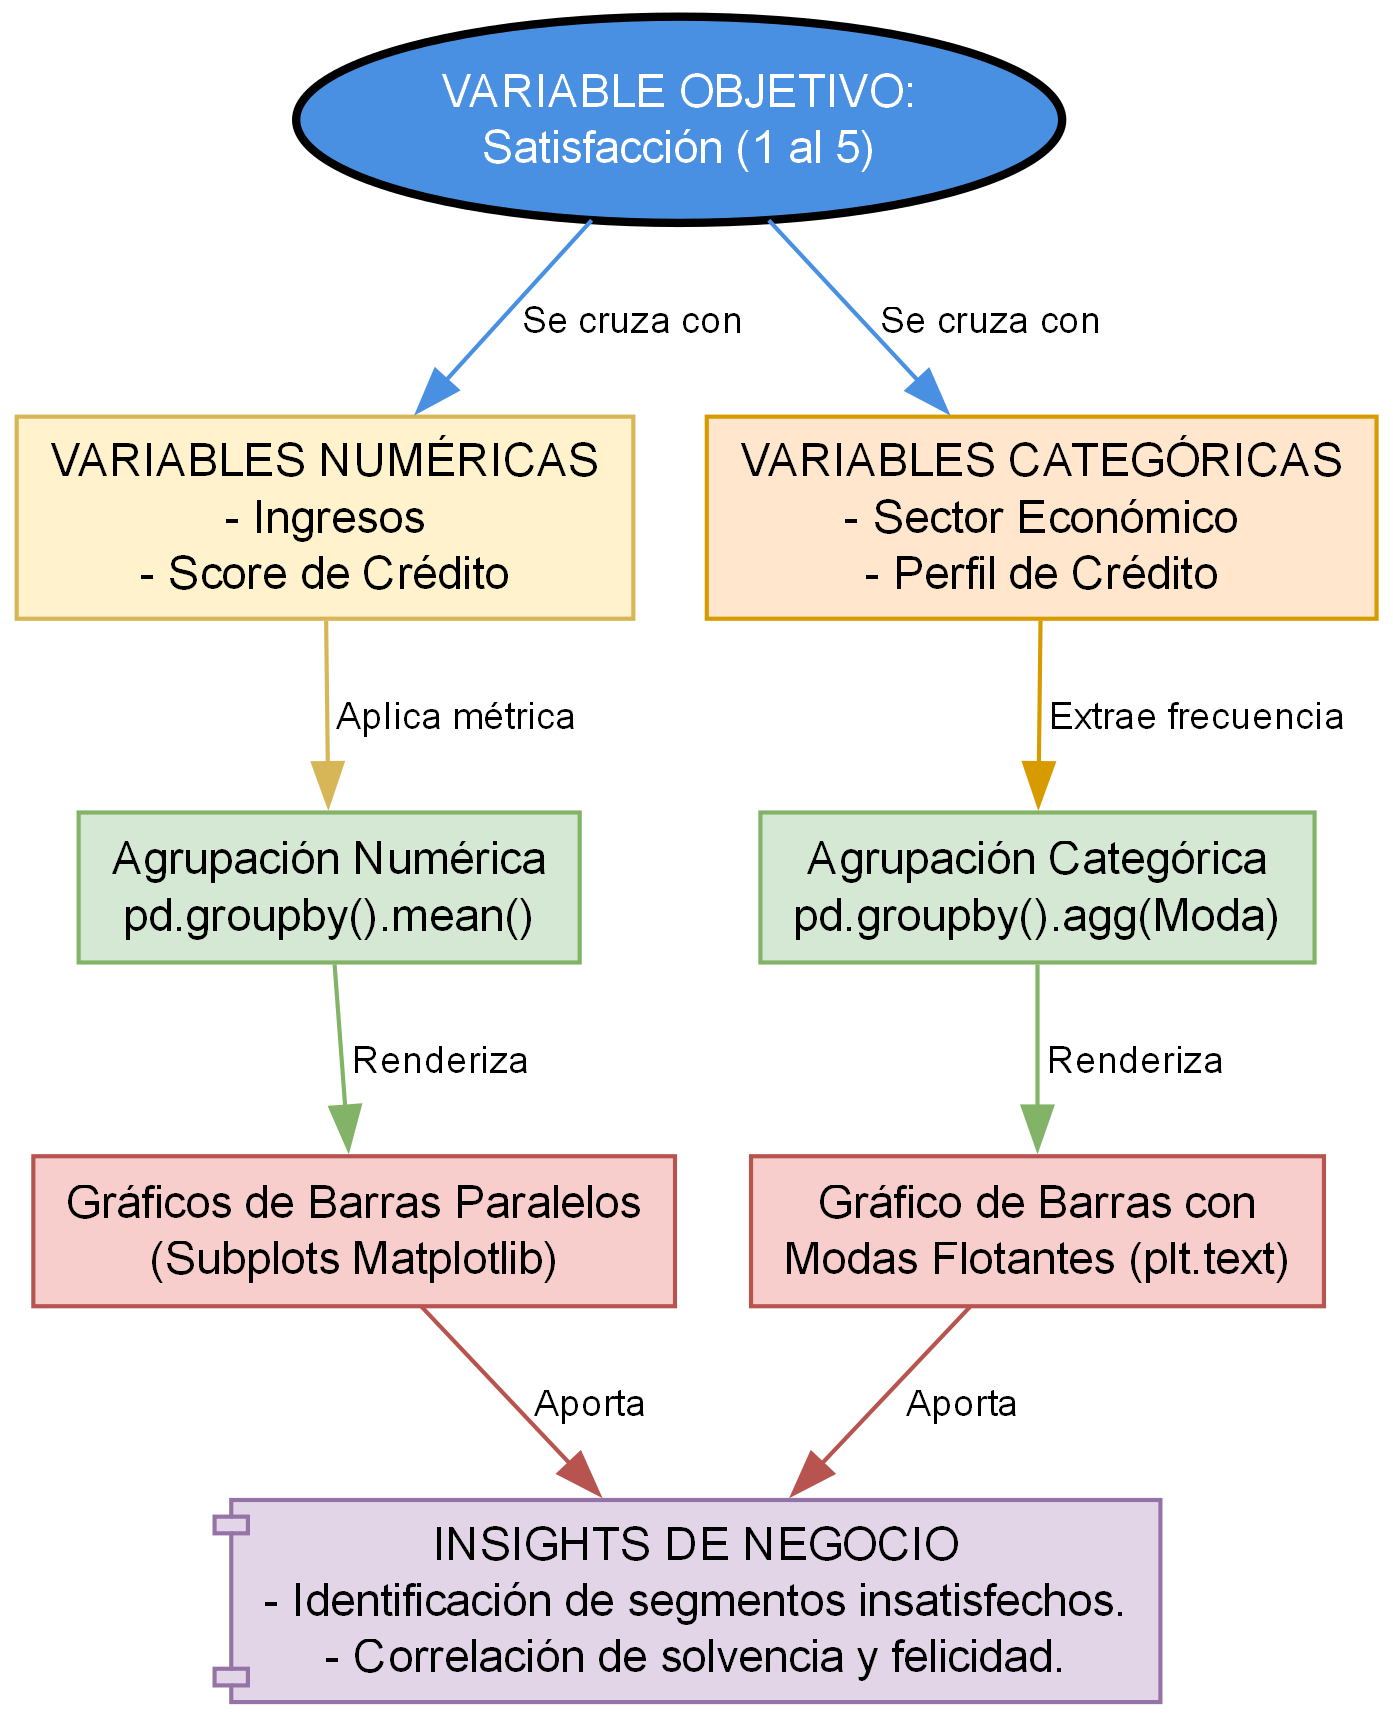

✅ ¡Mapa guardado en Descargas y renderizado con éxito en VS Code!


In [43]:
import graphviz
from IPython.display import display
from IPython.display import Image
# 1. Crear el objeto Digraph (orientado de arriba a abajo)
dot = graphviz.Digraph(comment='Mapa Conceptual Análisis de Satisfacción', format='png')
dot.attr(rankdir='TB', size='10,10', dpi='300')

# ==========================================
# CONFIGURACIÓN DE ESTILOS GLOBALES
# ==========================================
dot.attr('node', fontname='Helvetica,Arial,sans-serif', fontsize='11', shape='box', style='filled')
dot.attr('edge', fontname='Helvetica,Arial,sans-serif', fontsize='9', fontweight='bold')

# ==========================================
# CREACIÓN DE NODOS (Método .node())
# ==========================================

# Nodo Raíz (Variable Objetivo)
dot.node('VO', 'VARIABLE OBJETIVO:\nSatisfacción (1 al 5)', 
         fillcolor='#4A90E2', fontcolor='white', style='filled,bold', shape='ellipse')

# Bloque Variables Numéricas
dot.node('VN', 'VARIABLES NUMÉRICAS\n- Ingresos\n- Score de Crédito', 
         fillcolor='#FFF2CC', fontcolor='black', color='#D6B656')

dot.node('GB_NUM', 'Agrupación Numérica\npd.groupby().mean()', 
         fillcolor='#D5E8D4', fontcolor='black', color='#82B366')

dot.node('GRAF_NUM', 'Gráficos de Barras Paralelos\n(Subplots Matplotlib)', 
         fillcolor='#F8CECC', fontcolor='black', color='#B85450')

# Bloque Variables Categóricas
dot.node('VC', 'VARIABLES CATEGÓRICAS\n- Sector Económico\n- Perfil de Crédito', 
         fillcolor='#FFE6CC', fontcolor='black', color='#D79B00')

dot.node('GB_CAT', 'Agrupación Categórica\npd.groupby().agg(Moda)', 
         fillcolor='#D5E8D4', fontcolor='black', color='#82B366')

dot.node('GRAF_CAT', 'Gráfico de Barras con\nModas Flotantes (plt.text)', 
         fillcolor='#F8CECC', fontcolor='black', color='#B85450')

# Nodo de Cierre (Insights de Negocio)
dot.node('OUT', 'INSIGHTS DE NEGOCIO\n- Identificación de segmentos insatisfechos.\n- Correlación de solvencia y felicidad.', 
         fillcolor='#E1D5E7', fontcolor='black', color='#9673A6', shape='component')

# ==========================================
# CREACIÓN DE ENLACES CON ETIQUETAS (Método .edge())
# ==========================================

# Flujo Numérico
dot.edge('VO', 'VN', label=' Se cruza con', color='#4A90E2')
dot.edge('VN', 'GB_NUM', label=' Aplica métrica', color='#D6B656')
dot.edge('GB_NUM', 'GRAF_NUM', label=' Renderiza', color='#82B366')
dot.edge('GRAF_NUM', 'OUT', label=' Aporta', color='#B85450')

# Flujo Categórico
dot.edge('VO', 'VC', label=' Se cruza con', color='#4A90E2')
dot.edge('VC', 'GB_CAT', label=' Extrae frecuencia', color='#D79B00')
dot.edge('GB_CAT', 'GRAF_CAT', label=' Renderiza', color='#82B366')
dot.edge('GRAF_CAT', 'OUT', label=' Aporta', color='#B85450')

# ==========================================
# SOLUCIÓN AL RENDERIZADO EN JUPYTER
# ==========================================
# Primero forzamos la visualización interactiva en la celda

# Segundo, ejecutamos el guardado físico en el disco de manera segura
try:
    dot.render(r"C:\Users\marco\Downloads\mapa_conceptual_analisis_satisfaccion", view=False)
    print("Archivo guardado correctamente en la ruta especificada.")
except Exception as e:
    print(f"Nota: El gráfico se visualiza arriba, pero el guardado en disco falló debido a la ruta del sistema o permisos: {e}")
    
datos_imagen = dot.pipe(format='png')

# 3. Forzamos la visualización de los bytes como una imagen real de IPython
display(Image(datos_imagen))
print("✅ ¡Mapa guardado en Descargas y renderizado con éxito en VS Code!")    

Para agrupar tu conjunto de datos según el nivel de **satisfacción** y calcular automáticamente el promedio de **todos** los demás atributos numéricos, la forma más limpia y directa en Pandas es utilizar `.groupby()` en combinación con el método `.mean()`.

Aquí tienes el código exacto que debes ejecutar en tu cuaderno de Jupyter:


In [33]:
# Agrupar por la columna 'satisfaccion' y calcular la media de las variables numéricas
resumen_satisfaccion = df_filtrado.groupby('satisfaccion', as_index=False).mean(numeric_only=True)

# Mostrar el DataFrame resultante de forma ordenada
resumen_satisfaccion


,satisfaccion,identificador_cliente,ingresos_mensuales_cop,score_credito
0,1.0,1054.000000,2.302468e+06,498.363636
1,2.0,1059.833333,2.319855e+06,540.500000
2,3.0,1051.666667,3.995409e+06,607.851852
3,4.0,1041.333333,4.630811e+06,680.708333
4,5.0,1051.400000,4.628358e+06,660.466667



# ¿Qué está pasando detalladamente bajo el capó?

Cuando ejecutas esta línea de código, Pandas realiza un proceso clásico en Ciencia de Datos conocido como **Split-Apply-Combine** (Dividir-Aplicar-Combinar):

1. **Split (Dividir):** Toma tu DataFrame original y separa los registros en "grupos" independientes. En tu caso, creará hasta 5 grupos (los clientes que calificaron con 1, con 2, con 3, etc.).
2. **Apply (Aplicar):** Toma las columnas que contienen números (como `ingresos_gasto` y `score_credito`) dentro de cada grupo y calcula su promedio (`.mean()`).
3. **Combine (Combinar):** Une los resultados de todos los grupos en una nueva tabla limpia y unificada.



# Explicación de los parámetros clave utilizados:

* **`numeric_only=True`:** Es un parámetro fundamental. Al incluirlo, le indicas explícitamente a Pandas que ignore las columnas que no se pueden promediar (como la `fecha`, el `id` o el `sector_economico` que son texto o fechas) y se concentre únicamente en las variables cuantitativas.
* **`as_index=False`:** Por defecto, Pandas convierte la columna por la que agrupas (`satisfaccion`) en el índice de la tabla. Al ponerlo en `False`, mantienes un formato de tabla estándar donde la satisfacción se queda como una columna normal, lo cual facilita enormemente si después deseas graficar este resumen con Matplotlib.

### 📊 ¿Qué información estratégica te va a entregar esta tabla?

Al mirar el resultado final en Jupyter, podrás analizar directamente el comportamiento del negocio: verás si los clientes con **satisfacción baja (1 o 2)** coinciden con promedios de `ingresos_gasto` muy altos o si su `score_credito` es más bajo, dándote respuestas claras sobre el perfil del cliente en la región.

Para visualizar de forma clara los promedios numéricos que acabamos de agrupar, lo ideal es generar **dos gráficos de barras en paralelo (subplots)**: uno para el promedio de ingresos y otro para el promedio del score de crédito. De esta forma, el eje horizontal mostrará el nivel de satisfacción (del 1 al 5) y la altura de las barras reflejará el comportamiento de cada variable.

Aquí tienes el bloque de código listo para ejecutar en tu cuaderno de Jupyter:


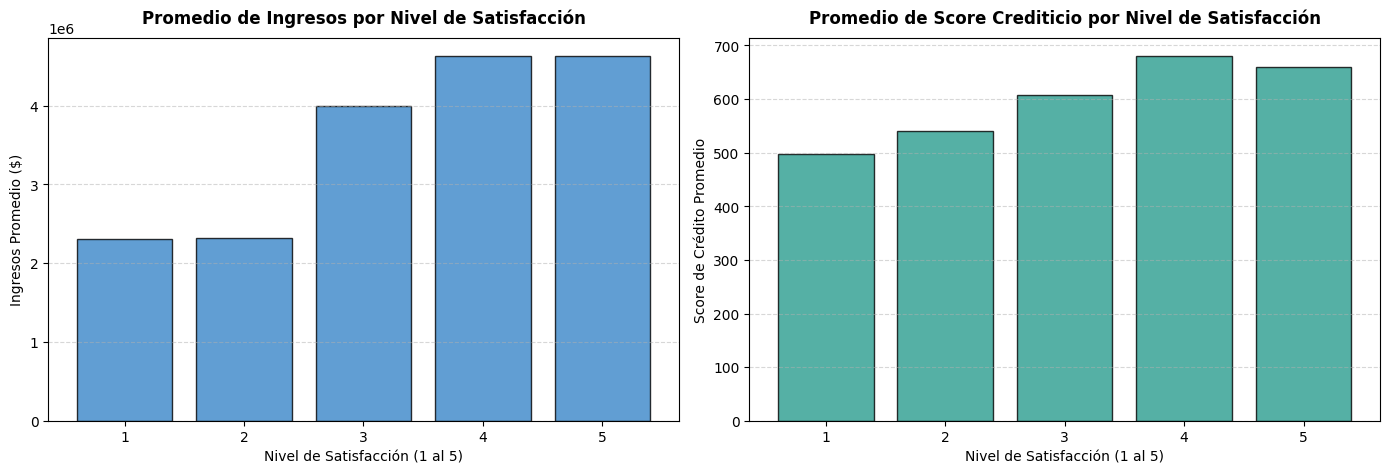

In [38]:
import matplotlib.pyplot as plt

# 1. Aseguramos que los datos agrupados existan (usando la tabla del paso anterior)
resumen = df_filtrado.groupby('satisfaccion', as_index=False).mean(numeric_only=True)

# 2. Configurar el lienzo para albergar dos gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------------
# GRÁFICO 1: Promedio de Ingresos según la Satisfacción
# ------------------------------------------------------------------
colores_ingresos = ['#e63946', '#f1faee', '#a8dadc', '#457b9d', '#1d3557'] # Paleta degradada o contrastante
ax1.bar(resumen['satisfaccion'], resumen['ingresos_mensuales_cop'], color='#3a86c8', edgecolor='black', alpha=0.8)

ax1.set_title('Promedio de Ingresos por Nivel de Satisfacción', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Nivel de Satisfacción (1 al 5)', fontsize=10)
ax1.set_ylabel('Ingresos Promedio ($)', fontsize=10)
ax1.set_xticks(resumen['satisfaccion']) # Asegura que se muestren los números 1, 2, 3, 4, 5 enteros
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# ------------------------------------------------------------------
# GRÁFICO 2: Promedio de Score de Crédito según la Satisfacción
# ------------------------------------------------------------------
ax2.bar(resumen['satisfaccion'], resumen['score_credito'], color='#2a9d8f', edgecolor='black', alpha=0.8)

ax2.set_title('Promedio de Score Crediticio por Nivel de Satisfacción', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Nivel de Satisfacción (1 al 5)', fontsize=10)
ax2.set_ylabel('Score de Crédito Promedio', fontsize=10)
ax2.set_xticks(resumen['satisfaccion'])
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# 3. Ajustar márgenes para evitar superposiciones
plt.tight_layout()

# Mostrar la composición
plt.savefig(r"C:\Users\marco\Downloads\grafico_comparativo_satisfaccion.png", dpi=300, bbox_inches='tight')  # Guarda el gráfico con alta resolución
plt.show()



# ¿Cómo interpretar este resultado en tu análisis?

Al ejecutar este código, el gráfico te permitirá extraer conclusiones inmediatas para el negocio:

* **En el primer gráfico:** Podrás ver si las barras más altas pertenecen a niveles de satisfacción bajos (lo que indicaría que tus clientes con más dinero están insatisfechos) o viceversa.
* **En el segundo gráfico:** Si la altura de las barras dedicadas al score de crédito asciende a medida que la satisfacción sube, comprobarías estadísticamente que los clientes con mejor comportamiento financiero son también los más felices con la marca.

Para agrupar por el nivel de **satisfacción** y extraer la **moda** (el valor que más se repite) de todos los atributos categóricos o de texto en tu dataset, la estructura cambia un poco. Dado que la moda puede devolver múltiples valores si hay un empate, la mejor práctica en Pandas es calcularla utilizando el método `.agg()` combinado con una función lambda que extraiga el primer resultado de la moda.

Aquí tienes el código exacto y optimizado para tu cuaderno de Jupyter:



In [35]:
# Agrupar por 'satisfaccion' y extraer la moda de los atributos categóricos
resumen_moda_categoricos = df_filtrado.groupby('satisfaccion', as_index=False).agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
)

# Como el método anterior aplica a todas las columnas, seleccionamos solo las de texto/fecha
columnas_categoricas = ['satisfaccion', 'sector_economico', 'perfil_credito']
resumen_moda_categoricos = resumen_moda_categoricos[columnas_categoricas]

# Mostrar el resultado limpio
resumen_moda_categoricos


,satisfaccion,sector_economico,perfil_credito
0,1.0,Comercio Minorista,Regular
1,2.0,Independientes,Regular
2,3.0,Comercio Minorista,Regular
3,4.0,Minería/Servicios,Excelente
4,5.0,Ganadería/Agro,Regular



# ¿Qué está pasando bajo el capó?

Cuando trabajamos con variables cualitativas (categóricas), no podemos calcular promedios ni sumas. Por lo tanto, recurrimos a la **estadística descriptiva de frecuencia** mediante el concepto de **Moda**:

1. **`groupby('satisfaccion')`:** Divide tu base de clientes de Caucasia en 5 bloques o grupos según las estrellas o calificación que hayan dejado.
2. **`x.mode().iloc[0]`:** Dentro de cada grupo, Pandas revisa la columna (por ejemplo, `sector_economico`), cuenta cuál es el sector que más se repite entre esos clientes específicos y toma el primero (`iloc[0]`) para evitar problemas si hay un empate entre dos sectores.



# ¿Cómo se interpreta el resultado estratégico en la consola?

La tabla resultante te dará una lectura directa del comportamiento del consumidor por perfiles, ideal para la toma de decisiones:

* Si en la fila de **satisfacción 1** (clientes muy insatisfechos), la moda del `sector_economico` es *'Minería/Servicios'*, sabrás de inmediato que ese sector específico está experimentando problemas graves con tu producto o atención.
* Si en la fila de **satisfacción 5** (clientes ideales), la moda de `perfil_credito` es *'Excelente'*, confirmas visualmente el segmento de clientes que debes blindar y fidelizar prioritariamente.

Para graficar variables categóricas (como el `sector_economico` o el `perfil_credito`) en función de la satisfacción, no podemos usar la altura de la barra directamente para representar un texto, ya que el eje vertical ($Y$) requiere valores numéricos para poder dibujar una altura.

Para resolver esto en Ciencia de Datos y Matplotlib de forma muy didáctica, lo que se grafica en el eje $Y$ es la **frecuencia (el conteo de cuántas veces aparece esa moda)** en cada nivel de satisfacción, y usamos **etiquetas de texto encima de las barras** para mostrar cuál fue la categoría ganadora (la moda).

Aquí tienes el código optimizado para generar este tipo de gráfico avanzado en tu cuaderno de Jupyter:



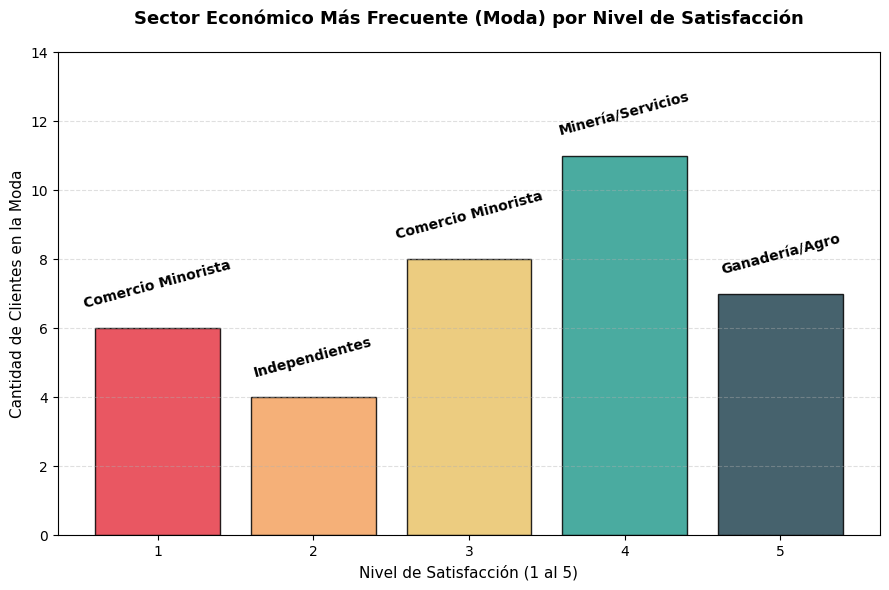

In [44]:
import matplotlib.pyplot as plt

# 1. Obtener la moda y su conteo para cada nivel de satisfacción
# Creamos un resumen que nos dé la moda y cuántas veces se repite (frecuencia)
resumen_modas = df_filtrado.groupby('satisfaccion')['sector_economico'].agg(
    moda=lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    frecuencia=lambda x: x.value_counts().iloc[0] if not x.value_counts().empty else 0
).reset_index()

# 2. Configurar el gráfico de barras
plt.figure(figsize=(9, 6))
colores_satisfaccion = ['#e63946', '#f4a261', '#e9c46a', '#2a9d8f', '#264653']

barras = plt.bar(
    resumen_modas['satisfaccion'], 
    resumen_modas['frecuencia'], 
    color=colores_satisfaccion, 
    edgecolor='black',
    alpha=0.85
)

# 3. El TRUCO: Agregar el texto de la moda encima de cada barra
for barra, moda in zip(barras, resumen_modas['moda']):
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2.0, # Posición X (centro de la barra)
        altura + 0.5,                          # Posición Y (un poco más arriba del tope)
        f'{moda}',                             # El texto que se va a mostrar
        ha='center',                           # Alineación horizontal centrada
        va='bottom',                           # Alineación vertical
        fontsize=10, 
        fontweight='bold',
        color='black',
        rotation=15                            # Una ligera rotación para que no se traslapen
    )

# 4. Diseño y etiquetas profesionales
plt.title('Sector Económico Más Frecuente (Moda) por Nivel de Satisfacción', \
    fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Nivel de Satisfacción (1 al 5)', fontsize=11)
plt.ylabel('Cantidad de Clientes en la Moda', fontsize=11)
plt.xticks(resumen_modas['satisfaccion'])

# Ampliamos el límite del eje Y un poco para que el texto de la barra más alta no se corte
plt.ylim(0, resumen_modas['frecuencia'].max() + 3)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Mostrar gráfico
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\grafico_barras_moda.png",\
    dpi=300, bbox_inches='tight')  # Guarda el gráfico con alta resolución
plt.show()



# ¿Cómo leer e interpretar este gráfico?

* **El eje horizontal ($X$):** Representa fielmente las notas de satisfacción de tus clientes (de 1 a 5).
* **La altura de la barra:** Te dice qué tan contundente es esa moda. Por ejemplo, si la barra del nivel 5 llega hasta el número 20, significa que hay 20 clientes en ese nivel que pertenecen al sector que está escrito arriba.
* **El texto flotante (Moda):** Te dice el "nombre y apellido" del sector predominante. Si arriba de la barra de satisfacción **1** dice *'Minería/Servicios'*, la gráfica te está gritando visualmente: *"¡Atención! El sector servicios es el que predomina entre la gente más insatisfecha, y representan un volumen de X clientes!"*.

# Visualización gráfica

## Visualización gráfica de atributos categóricos 



In [26]:
df_filtrado.columns

Index(['identificador_cliente', 'fecha_afiliacion', 'sector_economico',
       'ingresos_mensuales_cop', 'score_credito', 'perfil_credito',
       'satisfaccion'],
      dtype='str')

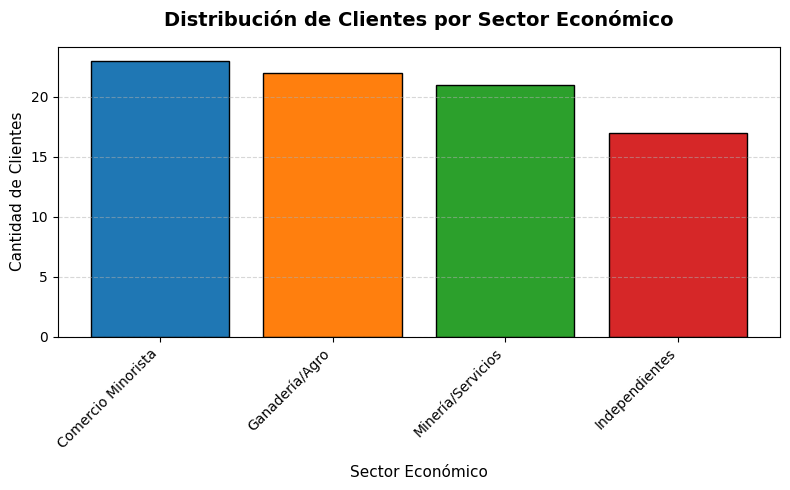

In [27]:
import matplotlib.pyplot as plt

# 1. Obtenemos los datos para no repetir código y ganar eficiencia
conteos_sectores = df_filtrado['sector_economico'].value_counts()
categorias = conteos_sectores.index
valores = conteos_sectores.values

# 2. Definimos una paleta de colores atractiva (puedes cambiarlos a tu gusto)
# Usamos 4 colores ya que definimos 4 sectores para Caucasia
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

# 3. Creamos la figura y el gráfico
plt.figure(figsize=(8, 5))
plt.bar(categorias, height=valores, color=colores, edgecolor='black')

# 4. Rotamos las subcategorías (eje X) a 45 grados y alineamos el texto
plt.xticks(rotation=45, ha='right', fontsize=10)

# 5. Agregamos etiquetas y diseño para que se vea profesional
plt.title('Distribución de Clientes por Sector Económico', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sector Económico', fontsize=11, labelpad=10)
plt.ylabel('Cantidad de Clientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5) # Rejilla tenue de fondo

# Ajustamos el diseño para que el texto rotado no se corte al guardar o mostrar
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 1. Preparar los datos
conteos_sectores = df_filtrado['sector_economico'].value_counts()
categorias = conteos_sectores.index
valores = conteos_sectores.values

# 2. Definir paleta de colores (puedes usar tonos pastel o corporativos)
colores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

# 3. Crear la figura
plt.figure(figsize=(7, 7))

# 4. Generar el gráfico de pastel
plt.pie(
    valores, 
    labels=categorias, 
    autopct='%1.1f%%',       # Muestra el porcentaje con un decimal automáticamente
    startangle=140,          # Rota el inicio del gráfico para una mejor perspectiva
    colors=colores, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}, # Separación elegante entre tajadas
    textprops={'fontsize': 11} # Tamaño de la fuente de las etiquetas
)

# 5. Título y diseño
plt.title('Proporción de Clientes por Sector Económico', fontsize=14, fontweight='bold', pad=20)

# Asegura que el gráfico de pastel sea un círculo perfecto y no un óvalo
plt.axis('equal')  

# Mostrar gráfico
plt.savefig(r"C:\Users\marco\Downloads\grafico_pastel_sectores.png", dpi=300, bbox_inches='tight')  # Guarda el gráfico con alta resolución
plt.show()


# 5. Realizando el Análisis de Datos y Graficando el Resumen

> Fase de conclusiones. Agrupamos los datos para responder al planteamiento del problema y creamos visualizaciones profesionales con Matplotlib.



In [ ]:
# 5.1 Agrupación de Datos (Insights)
# ¿Cuál es el ingreso promedio y la satisfacción según la categoría del producto?
resumen_categoria = df_filtrado.groupby('sector_economico').agg(
    ingreso_promedio=('ingresos_mensuales_cop', 'mean'),
    satisfaccion_promedio=('satisfaccion', 'mean'),
    total_clientes=('id_cliente', 'count')
).reset_index()

print("--- Resumen Ejecutivo por Categoría ---")
resumen_categoria


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5.2 Visualización de Resultados
plt.figure(figsize=(15, 6))

# -------------------------------------------------------------------------
# Gráfico 1: Relación entre Ingresos (COP) y Score de Crédito en Caucasia
# -------------------------------------------------------------------------
plt.subplot(1, 2, 1)
# Adaptado a: 'ingresos_mensuales_cop'
scatter = plt.scatter(df_filtrado['ingresos_mensuales_cop'], df_filtrado['score_credito'], 
                      c=df_filtrado['satisfaccion'], cmap='viridis', alpha=0.7, edgecolors='black', s=50)

# Líneas guía basadas en las medianas del contexto local
plt.axvline(df_filtrado['ingresos_mensuales_cop'].median(), color='red', linestyle=':', alpha=0.6, label='Mediana Ingresos')
plt.axhline(df_filtrado['score_credito'].median(), color='blue', linestyle=':', alpha=0.6, label='Mediana Score')

plt.title('Análisis de Clientes en Caucasia: Ingresos vs Score\n(Color según Nivel de Satisfacción)', fontsize=12, fontweight='bold')
# Formateamos el eje X para que no muestre números en notación científica (ej. 1e6)
plt.ticklabel_format(style='plain', axis='x') 
plt.xlabel('Ingresos Mensuales (COP $)')
plt.ylabel('Score de Crédito (Datacrédito / Cifín)')
plt.colorbar(scatter, label='Nivel de Satisfacción (1 al 5)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)


# -------------------------------------------------------------------------
# Gráfico 2: Cantidad de clientes por perfil de riesgo crediticio
# -------------------------------------------------------------------------
plt.subplot(1, 2, 2)
perfiles = df_filtrado['perfil_credito'].value_counts()

# Colores lógicos: Verde para Premium, Amarillo para Medio, Rojo para Alto Riesgo
# Ordenamos el índice para que la asignación de color sea coherente si aparecen en otro orden
perfiles = perfiles.reindex(['Premium / Excelente', 'Riesgo Medio', 'Alto Riesgo']).dropna()

colores_dict = {'Premium / Excelente': '#4CAF50', 'Riesgo Medio': '#FFC107', 'Alto Riesgo': '#F44336'}
colores = [colores_dict[p] for p in perfiles.index]

bars = plt.bar(perfiles.index, perfiles.values, color=colores, edgecolor='black')

plt.title('Distribución de Clientes por Perfil de Riesgo', fontsize=12, fontweight='bold')
plt.xlabel('Perfil de Crédito')
plt.ylabel('Número de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas de cantidad sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(perfiles.values)*0.01), 
             f'{int(yval)}', ha='center', va='bottom', fontweight='bold')


# Ajustar y guardar en la ruta local
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\analisis_clientes_caucasia.png", dpi=300)
plt.show()



In [ ]:

# -------------------------------------------------------------------------
# TEXTO DE APOYO: Diagnóstico Administrativo Automatizado
# -------------------------------------------------------------------------
print("-" * 70)
print("DIAGNÓSTICO ADMINISTRATIVO AUTOMÁTICO (CONTEXTO CAUCASIA):")
print("-" * 70)

# 1. Análisis por Sector Económico (Crucial para el Administrador)
sat_por_sector = df_filtrado.groupby('sector_economico')['satisfaccion'].mean().sort_values()
peor_sector = sat_por_sector.index[0]
peor_sat_sector = sat_por_sector.values[0]
print(f"• Alerta de Fuga: El SECTOR ECONÓMICO con MENOR satisfacción promedio es:\n"
      f"  '{peor_sector}' con una nota de {peor_sat_sector:.2f}/5.0")

# 2. Análisis por Perfil de Riesgo
sat_por_perfil = df_filtrado.groupby('perfil_credito')['satisfaccion'].mean().sort_values()
peor_perfil = sat_por_perfil.index[0]
peor_sat_perfil = sat_por_perfil.values[0]
print(f"• Impacto Financiero: El PERFIL DE CRÉDITO más insatisfecho es:\n"
      f"  '{peor_perfil}' con una nota de {peor_sat_perfil:.2f}/5.0")

# 3. Correlación de ingresos adaptada a la nueva variable
correlacion = df_filtrado['ingresos_mensuales_cop'].corr(df_filtrado['satisfaccion'])
print(f"• Correlación matemática entre Ingresos y Satisfacción: {correlacion:.2f}")
if correlacion > 0.2:
    print("  CONCLUSIÓN: A mayores ingresos en la región, la satisfacción sube. La fuga está en los microempresarios de bajos recursos.")
elif correlacion < -0.2:
    print("  CONCLUSIÓN: Curiosamente, a mayores ingresos hay menor satisfacción. Revisar servicio premium.")
else:
    print("  CONCLUSIÓN: El nivel de ingresos no tiene una relación lineal directa con la satisfacción.\n"
          "                 La insatisfacción está ligada a un sector o perfil específico, no al dinero que ganan.")
print("-" * 70)


# Conclusiones de la Clase y Próximos Pasos



> 1. **Resultados Clave:** Se logró conectar los datos crudos con respuestas de negocio. Descubrimos qué segmentos tienen peores scores o ingresos y cómo afecta a la satisfacción.
> 2. **Buenas Prácticas:** La limpieza de nulos previno sesgos en los promedios calculados.
> 3. **Reto para el Alumno:** Replica este mismo flujo cambiando el método de imputación de nulos (por ejemplo, usando la media o eliminándolos) y compara si los gráficos varían significativamente.

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo](https://github.com/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/13_intro_sql.ipynb)

## Referentes 

[Libro guía Fundamentos de programación: Data Analysis with Python: Introducing NumPy, Pandas, Matplotlib, and Essential Elements of Python Programming (English Edition) [Kindle Edition]](https://read.amazon.com/?_encoding=UTF8&asin=B0BBB56L4X&consumptionLimitReached=false&deviceAccountIds=A1032123ZASLV79K77QP&hasMultimedia=false&requiredCapabilities=EBOK_PURCHASE_ALLOWED&ref=sr_rn_kfw) Este vínculo lo debo abrir con Chrome

# Taller Rápido de Análisis de Datos (30 minutos)



## Actividad Previa a la Clase

Este taller está diseñado para que los estudiantes lleguen a la clase principal con los datos listos y un análisis básico realizado, permitiendo enfocar la sesión principal en la interpretación y discusión de resultados.




## Instrucciones para Estudiantes

**Tiempo estimado:** 25-30 minutos

**Objetivo:**   

  * Generar, 
  * explorar y 
  * visualizar un dataset de clientes para identificar patrones de satisfacción.



## Parte 1: Generación del Dataset (5 minutos)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:

# Configurar reproducibilidad
np.random.seed(42)


In [ ]:

# 1. Crear datos de 100 clientes
numero_clientes = 100

# IDs de clientes
ids = range(1001, 1001 + numero_clientes)

# Sectores económicos (contexto local)
sectores = ['Comercio', 'Servicios', 'Industria', 'Tecnología']
sector_asignado = np.random.choice(sectores, numero_clientes, p = [0.4, 0.3, 0.2, 0.1])

# 2. Ingresos mensuales (en miles de pesos)
ingresos = []
for sector in sector_asignado:
    if sector == 'Industria':
        ing = np.random.normal(4_500, 800)  # Ingresos más altos
    elif sector == 'Tecnología':
        ing = np.random.normal(5_000, 1_000)
    elif sector == 'Servicios':
        ing = np.random.normal(3_200, 600)
    else:  # Comercio
        ing = np.random.normal(2_800, 500)
    ingresos.append(max(1200, ing))  # Mínimo 1.2M COP

ingresos = np.array(ingresos).round(0)

# 3. Score de crédito (escala 300-850)
score_credito = []
for ing in ingresos:
    score_base = 350 + (ing / 12)  # Relación con ingresos
    score = score_base + np.random.randint(-80, 80)
    score_credito.append(max(300, min(850, score)))

score_credito = np.array(score_credito).round(0)

# 4. Satisfacción del cliente (1-5) - CON PATRÓN OCULTO
satisfaccion = []
for i in range(numero_clientes):
    # 10% de datos nulos (para practicar limpieza)
    if np.random.rand() < 0.10:
        satisfaccion.append(np.nan)
        continue
    
    sector = sector_asignado[i]
    ing = ingresos[i]
    
    # REGLA DE NEGOCIO: Clientes de Comercio con ingresos bajos están insatisfechos
    if sector == 'Comercio' and ing < 3000:
        satisfaccion.append(np.random.choice([1, 2, 3], p=[0.5, 0.3, 0.2]))
    elif sector == 'Tecnología' and ing > 4500:
        satisfaccion.append(np.random.choice([4, 5], p=[0.3, 0.7]))
    else:
        satisfaccion.append(np.random.choice([3, 4, 5], p=[0.2, 0.5, 0.3]))

# 5. Crear DataFrame
df = pd.DataFrame({
    'id_cliente': ids,
    'sector': sector_asignado,
    'ingresos_mensuales_cop': ingresos,
    'score_credito': score_credito,
    'satisfaccion': satisfaccion
})

print("Dataset generado correctamente!")
print(f"Forma del dataset: {df.shape}")
print("\n Primeros registros:")
df.head()


## Parte 2: Limpieza y Exploración (8 minutos)


In [ ]:
# ============================================
# LIMPIEZA Y ANÁLISIS EXPLORATORIO
# ============================================

print("=" * 60)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 60)

# 1. Información general
print("\n INFORMACIÓN DEL DATASET:")
print("-" * 40)
df.info()

# 2. Estadísticas básicas
print("\n ESTADÍSTICAS DESCRIPTIVAS:")
print("-" * 40)
print(df.describe())

# 3. Verificar valores nulos
print("\n VALORES NULOS POR COLUMNA:")
print("-" * 40)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if any(nulos > 0) else "No hay valores nulos")

# 4. Limpiar nulos en satisfacción (si existen)
if df['satisfaccion'].isnull().sum() > 0:
    mediana_sat = df['satisfaccion'].median()
    df['satisfaccion'] = df['satisfaccion'].fillna(mediana_sat)
    print(f"\n🔧 Se imputaron {nulos['satisfaccion']} valores nulos con la mediana: {mediana_sat}")

# 5. Distribución por sector
print("\n DISTRIBUCIÓN POR SECTOR:")
print("-" * 40)
print(df['sector'].value_counts())


## Parte 3: Análisis por Grupos (5 minutos)


In [ ]:
# ============================================
# ANÁLISIS AGRUPADO
# ============================================

print("\n" + "=" * 60)
print("ANÁLISIS POR SECTOR ECONÓMICO")
print("=" * 60)

# 1. Resumen por sector
resumen_sector = df.groupby('sector').agg({
    'ingresos_mensuales_cop': ['mean', 'min', 'max'],
    'score_credito': 'mean',
    'satisfaccion': 'mean',
    'id_cliente': 'count'
}).round(1)

resumen_sector.columns = ['Ingreso_Promedio', 'Ingreso_Min', 'Ingreso_Max', 
                          'Score_Promedio', 'Satisfacción_Promedio', 'Total_Clientes']

print("\n Resumen por sector económico:")
print(resumen_sector)

# 2. Identificar el sector más crítico
peor_sector = resumen_sector['Satisfacción_Promedio'].idxmin()
peor_satisfaccion = resumen_sector.loc[peor_sector, 'Satisfacción_Promedio']

print(f"\n SECTOR CRÍTICO: {peor_sector}")
print(f"   → Satisfacción promedio: {peor_satisfaccion}/5.0")
print(f"   → Total de clientes: {resumen_sector.loc[peor_sector, 'Total_Clientes']}")

# 3. Correlación entre variables
print("\n CORRELACIONES:")
print("-" * 40)
correlaciones = df[['ingresos_mensuales_cop', 'score_credito', 'satisfaccion']].corr()
print(correlaciones.round(3))


## Parte 4: Visualización Rápida (7 minutos)



In [ ]:
# ============================================
# VISUALIZACIÓN DE DATOS
# ============================================

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Análisis de Satisfacción de Clientes', fontsize=16, fontweight='bold')

# Gráfico 1: Ingresos vs Satisfacción
ax1 = axes[0, 0]
scatter = ax1.scatter(df['ingresos_mensuales_cop'], df['satisfaccion'], 
                      c=df['score_credito'], cmap='RdYlGn', s=80, alpha=0.7)
ax1.set_xlabel('Ingresos Mensuales (COP miles)', fontsize=10)
ax1.set_ylabel('Nivel de Satisfacción (1-5)', fontsize=10)
ax1.set_title('Ingresos vs Satisfacción (color = Score crédito)', fontsize=11)
plt.colorbar(scatter, ax=ax1, label='Score Crédito')
ax1.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Satisfacción media')
ax1.legend()

# Gráfico 2: Satisfacción por sector (boxplot)
ax2 = axes[0, 1]
df.boxplot(column='satisfaccion', by='sector', ax=ax2)
ax2.set_title('Distribución de Satisfacción por Sector', fontsize=11)
ax2.set_xlabel('Sector Económico')
ax2.set_ylabel('Satisfacción (1-5)')
ax2.tick_params(axis='x', rotation=45)

# Gráfico 3: Distribución de ingresos por sector
ax3 = axes[1, 0]
sectores_unicos = df['sector'].unique()
posiciones = range(len(sectores_unicos))
medias_ingresos = [df[df['sector'] == s]['ingresos_mensuales_cop'].mean() for s in sectores_unicos]
colores_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
ax3.bar(posiciones, medias_ingresos, color=colores_bar[:len(sectores_unicos)], edgecolor='black')
ax3.set_xticks(posiciones)
ax3.set_xticklabels(sectores_unicos, rotation=45)
ax3.set_ylabel('Ingreso Promedio (COP miles)')
ax3.set_title('Ingreso Promedio por Sector', fontsize=11)

# Gráfico 4: Matriz de correlación
ax4 = axes[1, 1]
datos_corr = df[['ingresos_mensuales_cop', 'score_credito', 'satisfaccion']].corr()
im = ax4.imshow(datos_corr, cmap='coolwarm', vmin=-1, vmax=1)
ax4.set_xticks(range(3))
ax4.set_yticks(range(3))
ax4.set_xticklabels(['Ingresos', 'Score', 'Satisfacción'], rotation=45)
ax4.set_yticklabels(['Ingresos', 'Score', 'Satisfacción'])
plt.colorbar(im, ax=ax4, label='Correlación')

# Añadir valores en la matriz
for i in range(3):
    for j in range(3):
        ax4.text(j, i, f'{datos_corr.iloc[i, j]:.2f}', 
                ha='center', va='center', color='white' if abs(datos_corr.iloc[i, j]) > 0.5 else 'black')

ax4.set_title('Matriz de Correlación', fontsize=11)

plt.tight_layout()
plt.show()

print("\n Visualizaciones generadas correctamente!")


## Parte 5: Preguntas de Análisis (5 minutos para responder)



In [ ]:
# ============================================
# PREGUNTAS DE ANÁLISIS
# ============================================

print("\n" + "=" * 60)
print(" PREGUNTAS PARA RESPONDER")
print("=" * 60)

preguntas = [
    "1. ¿Qué sector tiene la satisfacción promedio más baja?",
    "2. ¿Existe correlación entre ingresos y satisfacción? ¿Qué significa?",
    "3. ¿Qué sector tiene el score de crédito más alto? ¿Por qué crees que ocurre?",
    "4. ¿Cuántos clientes tienen satisfacción menor a 3? ¿Qué porcentaje representan?",
    "5. ¿Qué recomendación le darías a la empresa basada en estos datos?"
]

for p in preguntas:
    print(f"\n{p}")

# Cálculos adicionales para responder
print("\n" + "=" * 40)
print("DATOS PARA RESPONDER:")
print("=" * 40)

# Respuesta pregunta 4
clientes_insatisfechos = df[df['satisfaccion'] < 3].shape[0]
porcentaje = (clientes_insatisfechos / len(df)) * 100
print(f"Clientes insatisfechos (satisfacción < 3): {clientes_insatisfechos}")
print(f"Porcentaje del total: {porcentaje:.1f}%")

# Respuesta pregunta 3
mejor_score_sector = df.groupby('sector')['score_credito'].mean().idxmax()
mejor_score_valor = df.groupby('sector')['score_credito'].mean().max()
print(f"\nSector con mejor score de crédito: {mejor_score_sector} ({mejor_score_valor:.0f})")

print("\n Taller completado!")
print("Guarda este notebook para la próxima clase donde discutiremos los resultados")


# Script Completo (Todo en una celda)

Si prefieres tener todo en una sola celda para ejecución rápida:



In [ ]:
# ============================================
# TALLER COMPLETO - ANÁLISIS DE DATOS (30 min)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:

# ---------- PARTE 1: GENERACIÓN ----------
#np.random.seed(42)
n_clientes = 100
ids = range(1001, 1001 + n_clientes)
sectores = ['Comercio', 'Servicios', 'Industria', 'Tecnología']
sector_asignado = np.random.choice(sectores, n_clientes, p = [0.4, 0.3, 0.2, 0.1])
sector_asignado

In [ ]:

ingresos = []
for sector in sector_asignado:
    if sector == 'Industria':
        ing = np.random.normal(4500, 800)
    elif sector == 'Tecnología':
        ing = np.random.normal(5000, 1000)
    elif sector == 'Servicios':
        ing = np.random.normal(3200, 600)
    else:
        ing = np.random.normal(2800, 500)
    ingresos.append(max(1200, ing))
ingresos = np.array(ingresos).round(0)
ingresos 

In [ ]:

score_credito = []
for ing in ingresos:
    score = 350 + (ing / 12) + np.random.randint(-80, 80)
    score_credito.append(max(300, min(850, score)))
score_credito = np.array(score_credito).round(0)
score_credito 

In [ ]:

satisfaccion = []
for i in range(n_clientes):
    if np.random.rand() < 0.10:
        satisfaccion.append(np.nan)
        continue
    sector = sector_asignado[i]
    ing = ingresos[i]
    if sector == 'Comercio' and ing < 3000:
        satisfaccion.append(np.random.choice([1, 2, 3], p=[0.5, 0.3, 0.2]))
    elif sector == 'Tecnología' and ing > 4500:
        satisfaccion.append(np.random.choice([4, 5], p=[0.3, 0.7]))
    else:
        satisfaccion.append(np.random.choice([3, 4, 5], p=[0.2, 0.5, 0.3]))
satisfaccion  

In [ ]:

df = pd.DataFrame({
    'id_cliente': ids, 'sector': sector_asignado,
    'ingresos_mensuales_cop': ingresos, 'score_credito': score_credito,
    'satisfaccion': satisfaccion
})
df  

In [ ]:

# ---------- PARTE 2: LIMPIEZA ----------
if df['satisfaccion'].isnull().sum() > 0:
    df['satisfaccion'] = df['satisfaccion'].fillna(df['satisfaccion'].median())


In [ ]:

# ---------- PARTE 3: ANÁLISIS ----------
print("=" * 60)
print("RESULTADOS DEL ANÁLISIS")
print("=" * 60)

resumen = df.groupby('sector').agg({
    'ingresos_mensuales_cop': 'mean',
    'score_credito': 'mean',
    'satisfaccion': 'mean',
    'id_cliente': 'count'
}).round(1)
resumen.columns = ['Ingreso_Prom', 'Score_Prom', 'Satisfacción', 'Clientes']
print("\n", resumen)

peor = resumen['Satisfacción'].idxmin()
print(f"\n SECTOR CRÍTICO: {peor} (Satisfacción: {resumen.loc[peor, 'Satisfacción']}/5)")

insatisfechos = df[df['satisfaccion'] < 3].shape[0]
print(f"Clientes insatisfechos: {insatisfechos} ({insatisfechos/len(df)*100:.0f}%)")


In [ ]:

# ---------- PARTE 4: VISUALIZACIÓN ----------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Análisis de Satisfacción de Clientes', fontsize=14, fontweight='bold')

axes[0,0].scatter(df['ingresos_mensuales_cop'], df['satisfaccion'], 
                  c=df['score_credito'], cmap='RdYlGn', s=60, alpha=0.7)
axes[0,0].set_xlabel('Ingresos (COP miles)')
axes[0,0].set_ylabel('Satisfacción')
axes[0,0].set_title('Ingresos vs Satisfacción')
axes[0,0].axhline(y=3, color='red', linestyle='--')

df.boxplot(column='satisfaccion', by='sector', ax=axes[0,1])
axes[0,1].set_title('Satisfacción por Sector')
axes[0,1].tick_params(axis='x', rotation=45)

sectores_u = df['sector'].unique()
medias = [df[df['sector']==s]['ingresos_mensuales_cop'].mean() for s in sectores_u]
axes[1,0].bar(range(len(sectores_u)), medias, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[1,0].set_xticks(range(len(sectores_u)))
axes[1,0].set_xticklabels(sectores_u, rotation=45)
axes[1,0].set_ylabel('Ingreso Promedio')
axes[1,0].set_title('Ingresos por Sector')

corr = df[['ingresos_mensuales_cop', 'score_credito', 'satisfaccion']].corr()
im = axes[1,1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(3))
axes[1,1].set_yticks(range(3))
axes[1,1].set_xticklabels(['Ingresos', 'Score', 'Satisfacción'], rotation=45)
axes[1,1].set_yticklabels(['Ingresos', 'Score', 'Satisfacción'])
for i in range(3):
    for j in range(3):
        axes[1,1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center')
plt.colorbar(im, ax=axes[1,1])
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\analisis_clientes.png", dpi=300)
plt.show()

print("\n ¡Taller completado! Guarda este notebook para la próxima clase.")


# Hoja de Respuesta para Estudiantes



# TALLER PREVIO: ANÁLISIS DE DATOS
## Nombre: ______________________ Fecha: ______________

### RESPUESTAS:

**1. Sector con menor satisfacción promedio:** ________________

**2. Correlación ingresos-satisfacción:** ______
   - ¿Qué significa este valor? _______________________________________________

**3. Sector con mejor score de crédito:** ________________
   - Posible explicación: ____________________________________________________

**4. Clientes insatisfechos:** ______ de ______ (______%)
   - ¿Qué patrón observas en estos clientes? _________________________________

**5. Recomendaciones para la empresa:**
   1. ________________________________________________________________
   2. ________________________________________________________________
   3. ________________________________________________________________

### PREGUNTA EXTRA (Análisis propio):
¿Qué otra relación entre variables te gustaría explorar? _______________________
___________________________________________________________________________




## Expectativas para la Clase Principal

Al llegar a clase, los estudiantes deben tener:
1.  El dataset generado y limpio
2.  Las visualizaciones básicas creadas
2.  Respuestas preliminares a las 5 preguntas
3.  Al menos 1 observación interesante no solicitada



**La clase principal se enfocará en:**
- Discutir los hallazgos en grupo
- Comparar diferentes estrategias de limpieza
- Introducir técnicas avanzadas (regresión, clustering)
- Aplicar los resultados a un caso de negocio real

